# Phase 4.5: Neural Network Baseline & Tuning 


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
import mlflow
import sys
import copy

sys.path.append('../')
from src.metrics import zindi_score

# Setup MLflow
# mlflow.set_tracking_uri('sqlite:///../mlflow.db')
# mlflow.set_experiment('Zindi_Liquidity_Stress')

# set device
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

/Users/USER/Desktop/zindi/ml_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


In [2]:
# data Preparation
train_df = pd.read_parquet('../data/features/train_features.parquet', engine='fastparquet')
raw_train = pd.read_csv('../data/Train.csv')
target = raw_train['liquidity_stress_next_30d']

X = train_df.drop(columns=['ID', 'liquidity_stress_next_30d'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

class ZindiDataset(Dataset):
    def __init__(self, features, labels=None):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels.values, dtype=torch.float32) if labels is not None else None
        
    def __len__(self):
        return len(self.features)
        
    def __getitem__(self, idx):
        if self.labels is not None:
            return self.features[idx], self.labels[idx]
        return self.features[idx]


## 2. Upgraded Architecture (GELU + Wider Layers)

In [3]:
class LiquidityNN(nn.Module):
    def __init__(self, input_dim):
        super(LiquidityNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),  # Widen to 512
            nn.BatchNorm1d(512),
            nn.GELU(),                  # Upgrade to GELU
            nn.Dropout(0.3),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.2),
            
            nn.Linear(128, 1)
        )
        
    def forward(self, x):
        return self.net(x)

## 3. Early Stopping Helper Class

In [4]:
class EarlyStopping:
    def __init__(self, patience=15, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False
        self.best_weights = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            # Save the best model weights
            self.best_weights = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

## 4. Advanced Training Loop (AdamW, Plateau Scheduler, Early Stopping, 150 Epochs)

In [5]:
EPOCHS = 150
BATCH_SIZE = 256
N_FOLDS = 5

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))

print("Starting Advanced NN Training...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, target)):
    print(f"\n--- Fold {fold+1} ---")
    
    # dataLoaders
    train_dataset = ZindiDataset(X_scaled[train_idx], target.iloc[train_idx])
    val_dataset = ZindiDataset(X_scaled[val_idx], target.iloc[val_idx])
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    # initialize model, loss, optimizer
    model = LiquidityNN(input_dim=X_scaled.shape[1]).to(device)
    criterion = nn.BCEWithLogitsLoss()
    
    optimizer = optim.AdamW(model.parameters(), lr=0.003, weight_decay=1e-4)
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
    
    # Early Stopping (stops if no improvement for 15 epochs)
    early_stopper = EarlyStopping(patience=15, min_delta=0.0001)
    
    best_val_loss = float('inf')
    
    # Training Loop
    for epoch in range(EPOCHS):
        model.train()
        train_losses = []
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.unsqueeze(1).to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            
        # Validation Loop (Every epoch)
        model.eval()
        val_losses = []
        val_preds_epoch = []
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.unsqueeze(1).to(device)
                outputs = model(batch_x)
                v_loss = criterion(outputs, batch_y)
                val_losses.append(v_loss.item())
                probs = torch.sigmoid(outputs).cpu().numpy()
                val_preds_epoch.extend(probs)
        
        avg_val_loss = np.mean(val_losses)
        
        # Step Scheduler & Early Stopping
        scheduler.step(avg_val_loss)
        early_stopper(avg_val_loss, model)
        
        if (epoch + 1) % 10 == 0 or early_stopper.early_stop:
            lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1:03d} | Train Loss: {np.mean(train_losses):.4f} | Val Loss: {avg_val_loss:.4f} | LR: {lr:.6f}") # LR is for learning rate
        
        if early_stopper.early_stop:
            print("--- Early stopping triggered! Restoring best weights ---")
            break
            
    # After fold training is complete, load the best weights for this fold
    model.load_state_dict(early_stopper.best_weights)
    
    # Generate final out-of-fold predictions with the best model
    model.eval()
    val_preds_fold = []
    with torch.no_grad():
        for batch_x, _ in val_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            probs = torch.sigmoid(outputs).cpu().numpy()
            val_preds_fold.extend(probs)
            
    oof_preds[val_idx] = np.array(val_preds_fold).squeeze()
    
# Evaluate Total Pipeline
nn_loss, nn_auc = zindi_score(target, oof_preds)

# Log to MLflow
# with mlflow.start_run(run_name='PyTorch_NN_SOTA_Tuned'):
#     mlflow.log_param('model_type', 'PyTorch_MLP_AdamW_GELU')
#     mlflow.log_param('max_epochs', EPOCHS)
#     mlflow.log_param('batch_size', BATCH_SIZE)
#     mlflow.log_param('optimizer', 'AdamW')
#     mlflow.log_param('activation', 'GELU')
#     mlflow.log_metric('cv_logloss', nn_loss)
#     mlflow.log_metric('cv_auc', nn_auc)

Starting Advanced NN Training...

--- Fold 1 ---


Epoch 010 | Train Loss: 0.2894 | Val Loss: 0.3196 | LR: 0.003000
Epoch 020 | Train Loss: 0.2076 | Val Loss: 0.3692 | LR: 0.000300
Epoch 026 | Train Loss: 0.1922 | Val Loss: 0.3896 | LR: 0.000030
--- Early stopping triggered! Restoring best weights ---

--- Fold 2 ---
Epoch 010 | Train Loss: 0.2890 | Val Loss: 0.3334 | LR: 0.003000
Epoch 020 | Train Loss: 0.2207 | Val Loss: 0.3699 | LR: 0.000030
Epoch 023 | Train Loss: 0.2179 | Val Loss: 0.3705 | LR: 0.000030
--- Early stopping triggered! Restoring best weights ---

--- Fold 3 ---
Epoch 010 | Train Loss: 0.2935 | Val Loss: 0.3320 | LR: 0.003000
Epoch 020 | Train Loss: 0.2218 | Val Loss: 0.3639 | LR: 0.000300
Epoch 024 | Train Loss: 0.2139 | Val Loss: 0.3628 | LR: 0.000030
--- Early stopping triggered! Restoring best weights ---

--- Fold 4 ---
Epoch 010 | Train Loss: 0.2917 | Val Loss: 0.3213 | LR: 0.003000
Epoch 020 | Train Loss: 0.2196 | Val Loss: 0.3591 | LR: 0.000030
Epoch 023 | Train Loss: 0.2153 | Val Loss: 0.3548 | LR: 0.000030
-

## Overfitting Check

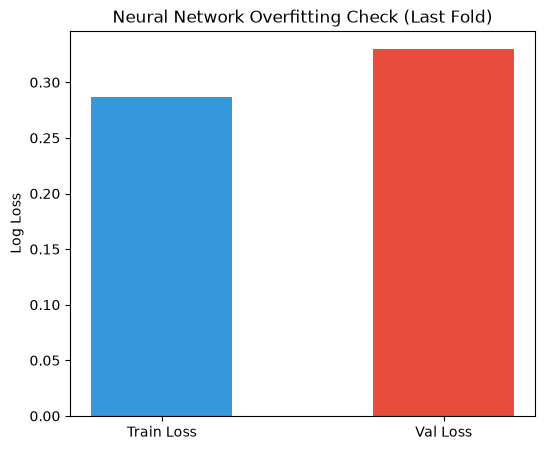

PyTorch NN - Train: 0.2869, Val: 0.3297, Gap: 0.0428


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import log_loss

def check_nn_overfitting():
    try:
        if 'model' not in globals() or 'train_loader' not in globals() or 'val_loader' not in globals():
            print("Model or DataLoaders not found in memory. Run the training loop first.")
            return
            
        model.eval()
        criterion = nn.BCEWithLogitsLoss()
        
        def get_loss(loader):
            losses = []
            with torch.no_grad():
                for batch_x, batch_y in loader:
                    batch_x = batch_x.to(device)
                    batch_y = batch_y.unsqueeze(1).to(device) if batch_y.ndim == 1 else batch_y.to(device)
                    outputs = model(batch_x)
                    loss = criterion(outputs, batch_y)
                    losses.append(loss.item())
            return np.mean(losses)
            
        train_loss = get_loss(train_loader)
        val_loss = get_loss(val_loader)
        
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.bar(['Train Loss', 'Val Loss'], [train_loss, val_loss], color=['#3498db', '#e74c3c'], width=0.5)
        ax.set_ylabel('Log Loss')
        ax.set_title('Neural Network Overfitting Check (Last Fold)')
        plt.show()
        
        print(f"PyTorch NN - Train: {train_loss:.4f}, Val: {val_loss:.4f}, Gap: {val_loss - train_loss:.4f}")
        
    except Exception as e:
        print(f"Could not run overfitting check: {e}")

check_nn_overfitting()